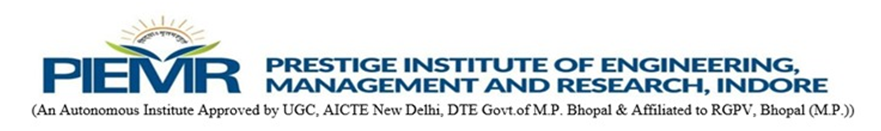

<h2 align="left">Department of AI & Data Science</h2>

<h2 align="left">Data Mining & Warehousing Lab </h2>

<h2 align="left"> Course Instructor: Dr. Rajesh Kumar</h2>


<h2 align="left">Experiment 6</h2>

<h2 align="left">Neural Network Classification using MLP</h2>

<h2 align="Left">Objective</h2>


To implement a Multi-Layer Perceptron (MLP) Neural Network for handwritten digit classification using the MNIST dataset and evaluate its performance using:


Accuracy

Confusion Matrix

Classification Report

Visualization of predictions


Python Libraries Used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report



STEP 1: Load Dataset
Dataset Used

MNIST Handwritten Digits Dataset

Files:

mnist_train.csv

mnist_test.csv

In [2]:
train_path = r"C:\Users\rjesh\mnist_train.csv"
test_path = r"C:\Users\rjesh\mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)



STEP 2: Explore Dataset

In [3]:
print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

print(train_df.head())



Training Shape: (60000, 785)
Testing Shape: (10000, 785)
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]


Explanation

First column = target label (digit)

Remaining 784 columns = image pixels

Each image size: 28 × 28 = 784 pixels



STEP 3: Separate Features and Labels
Training Data

In [4]:
X_train = train_df.iloc[:, 1:]
y_train = train_df.iloc[:, 0]



Testing Data

In [5]:
X_test = test_df.iloc[:, 1:]
y_test = test_df.iloc[:, 0]



Explanation
Features (X)

Pixel intensity values.

Labels (y)

Actual handwritten digit.

STEP 4: Normalize Data

Neural networks perform better when data is scaled.

Original pixel range: 0 → 255  

0 → 1


In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0



Steo 5: Visualize Sample Images

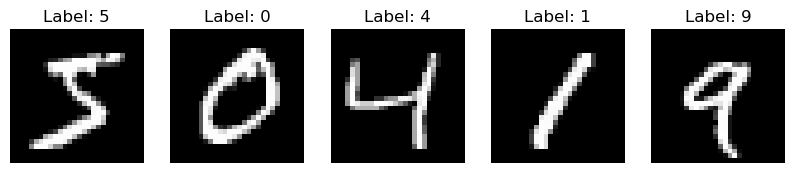

In [7]:
plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    image = X_train.iloc[i].values.reshape(28,28)

    plt.imshow(image, cmap='gray')

    plt.title(f"Label: {y_train.iloc[i]}")

    plt.axis('off')

plt.show()

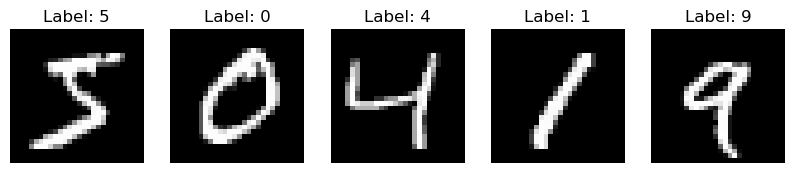

In [8]:
plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    image = X_train.iloc[i].values.reshape(28,28)

    plt.imshow(image, cmap='gray')

    plt.title(f"Label: {y_train.iloc[i]}")

    plt.axis('off')

plt.show()



Explanation

This step verifies:

images loaded correctly
labels match images

STEP 6: Create MLP Model

In [9]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=20,
    random_state=42
)



Parameter Explanation

Parameter	Meaning

hidden_layer_sizes=(100,)	

100 neurons in hidden layer

activation='relu'

ReLU activation
solver='adam'
Optimization algorithm

max_iter=20	

Number of training iterations

random_state=42	Reproducible results



STEP 7: Train Neural Network

In [10]:
mlp.fit(X_train, y_train)



C:\Users\rjesh\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,20
,shuffle,True
,random_state,42


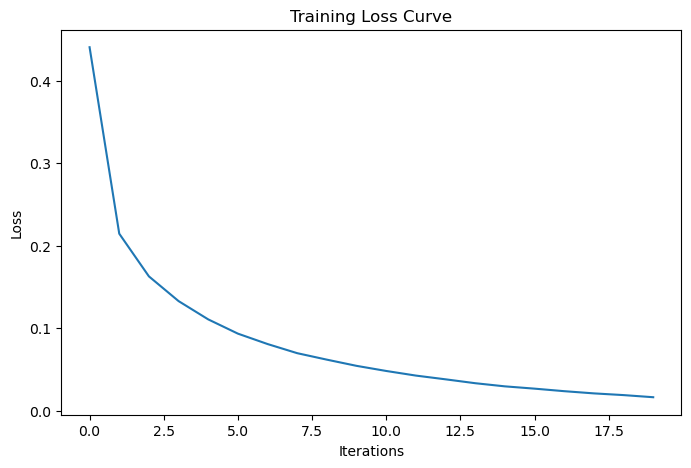

In [11]:
plt.figure(figsize=(8,5))

plt.plot(mlp.loss_curve_)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.show()

Explanation


During training:


weights are updated

backpropagation occurs

model learns digit patterns

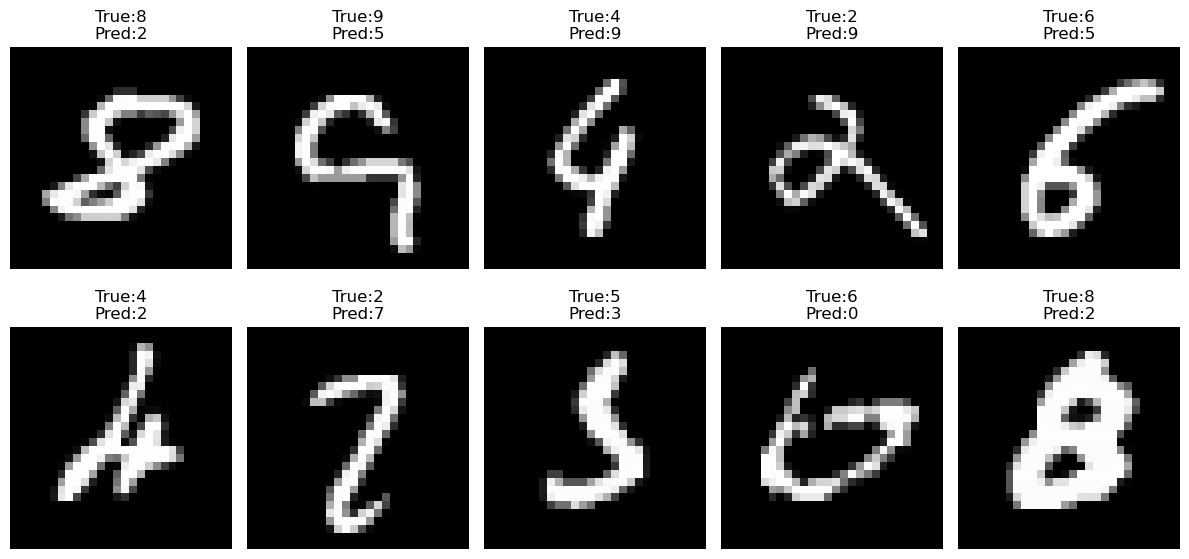

In [14]:
y_pred = mlp.predict(X_test)

misclassified = np.where(y_test != y_pred)[0]

plt.figure(figsize=(12,6))

for i, index in enumerate(misclassified[:10]):

    plt.subplot(2,5,i+1)

    image = X_test.iloc[index].values.reshape(28,28)

    plt.imshow(image, cmap='gray')

    plt.title(
        f"True:{y_test.iloc[index]}\nPred:{y_pred[index]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()


Explanation

The trained model predicts:

0,1,2,3,...9

for unseen handwritten images.

 STEP 9: Accuracy Calculation
 
Formula


Accuracy=
Total Predictions/Correct Predictions


In [15]:
errors = np.sum(y_test != y_pred)

print("Total Misclassified Images:", errors)

Total Misclassified Images: 241


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)



Accuracy: 0.9759


In [16]:
print("Input Neurons:", X_train.shape[1])
print("Hidden Neurons:", 100)
print("Output Classes:", len(np.unique(y_train)))

Input Neurons: 784
Hidden Neurons: 100
Output Classes: 10


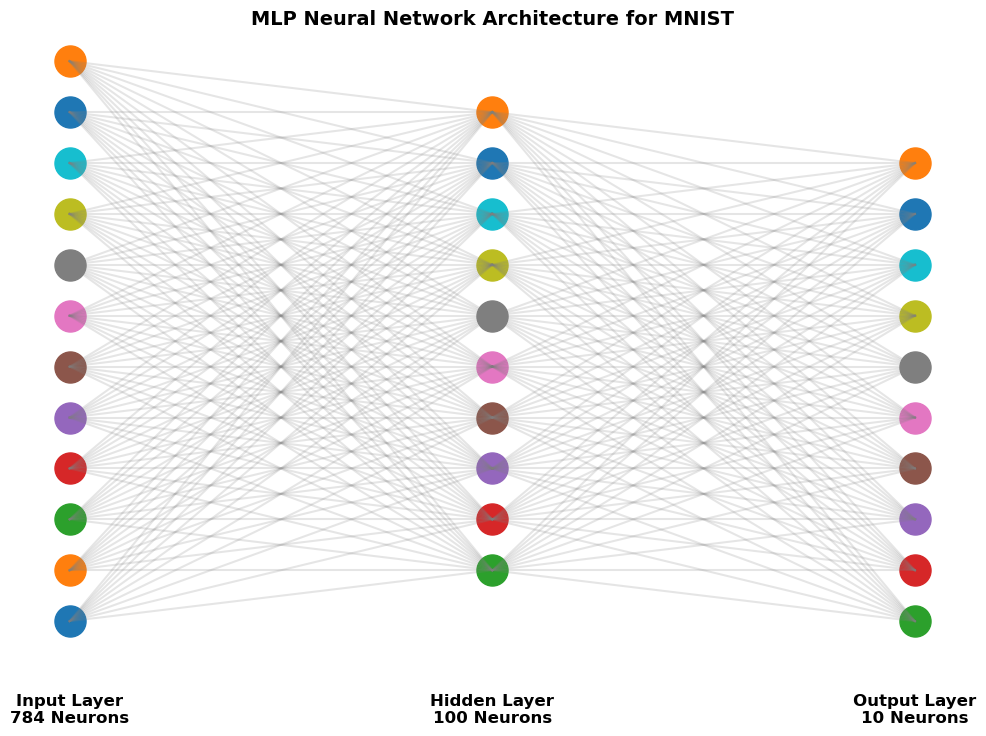

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# Number of representative neurons to display
input_nodes = 12
hidden_nodes = 10
output_nodes = 10

# Input Layer
for i in range(input_nodes):
    plt.scatter(1, i, s=500)

# Hidden Layer
for i in range(hidden_nodes):
    plt.scatter(2, i+1, s=500)

# Output Layer
for i in range(output_nodes):
    plt.scatter(3, i, s=500)

# Connections: Input → Hidden
for i in range(input_nodes):
    for j in range(hidden_nodes):
        plt.plot([1,2],[i,j+1],'gray',alpha=0.2)

# Connections: Hidden → Output
for i in range(hidden_nodes):
    for j in range(output_nodes):
        plt.plot([2,3],[i+1,j],'gray',alpha=0.2)

# Labels
plt.text(1,-2,"Input Layer\n784 Neurons",
         ha='center',fontsize=12,fontweight='bold')

plt.text(2,-2,"Hidden Layer\n100 Neurons",
         ha='center',fontsize=12,fontweight='bold')

plt.text(3,-2,"Output Layer\n10 Neurons",
         ha='center',fontsize=12,fontweight='bold')

plt.title("MLP Neural Network Architecture for MNIST",
          fontsize=14,fontweight='bold')

plt.axis('off')
plt.show()

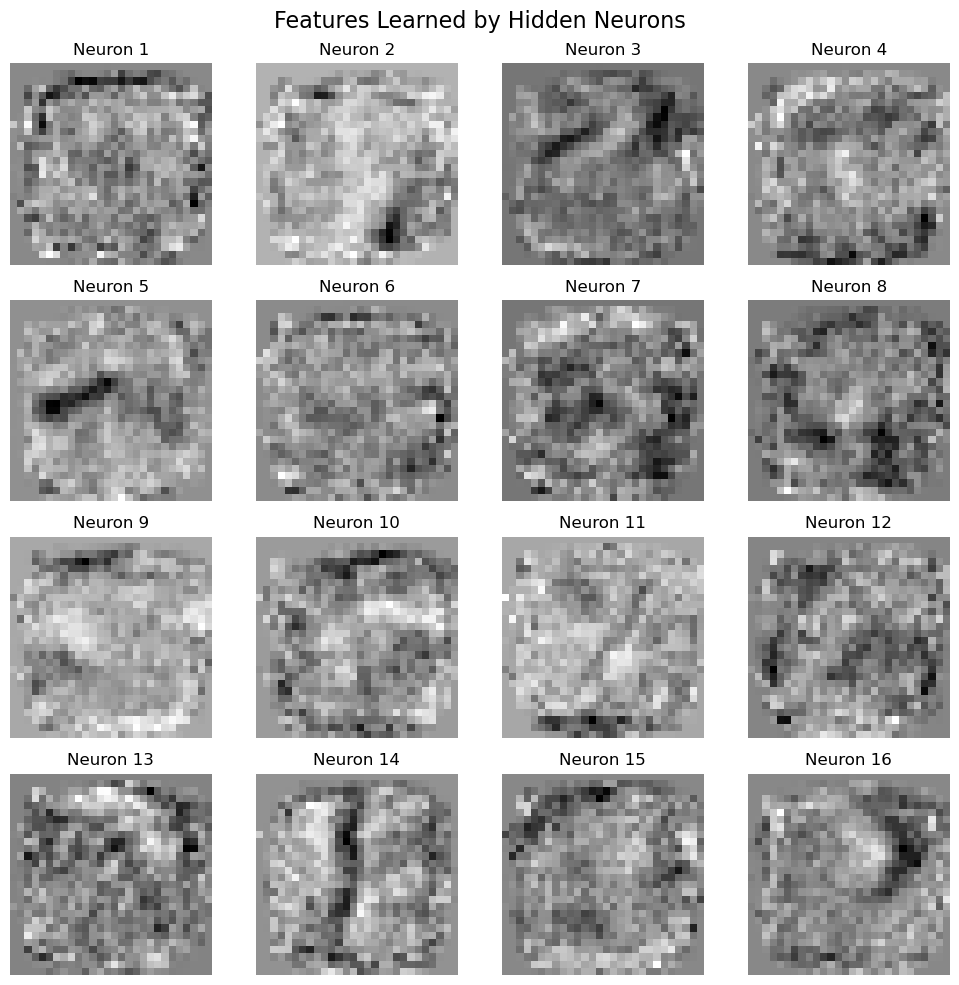

In [19]:
weights = mlp.coefs_[0]

plt.figure(figsize=(10,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        weights[:,i].reshape(28,28),
        cmap='gray'
    )

    plt.title(f"Neuron {i+1}")

    plt.axis('off')

plt.suptitle("Features Learned by Hidden Neurons",
             fontsize=16)

plt.tight_layout()

plt.show()

STEP 10: Confusion Matrix Visualization

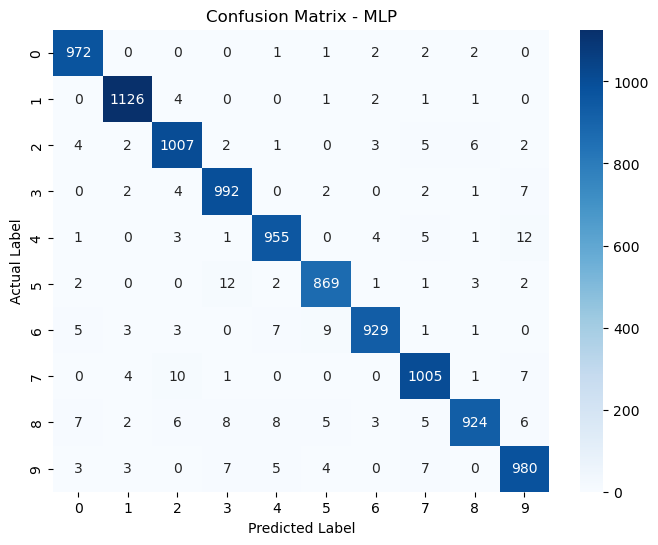

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - MLP")

plt.show()



Explanation


Confusion Matrix shows:

correct predictions

incorrect classifications

class-wise performance


Diagonal values = correct predictions.




STEP 11: Classification Report

In [16]:
print(classification_report(y_test, y_pred))




              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.97      0.97       982
           5       0.98      0.97      0.97       892
           6       0.98      0.97      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.98      0.95      0.97       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



Metrics Explained
| Metric    | Meaning                         |
| --------- | ------------------------------- |
| Precision | Correct positive predictions    |
| Recall    | Ability to find all positives   |
| F1-score  | Balance of precision and recall |
| Support   | Number of samples               |





STEP 12: Visualize Predictions

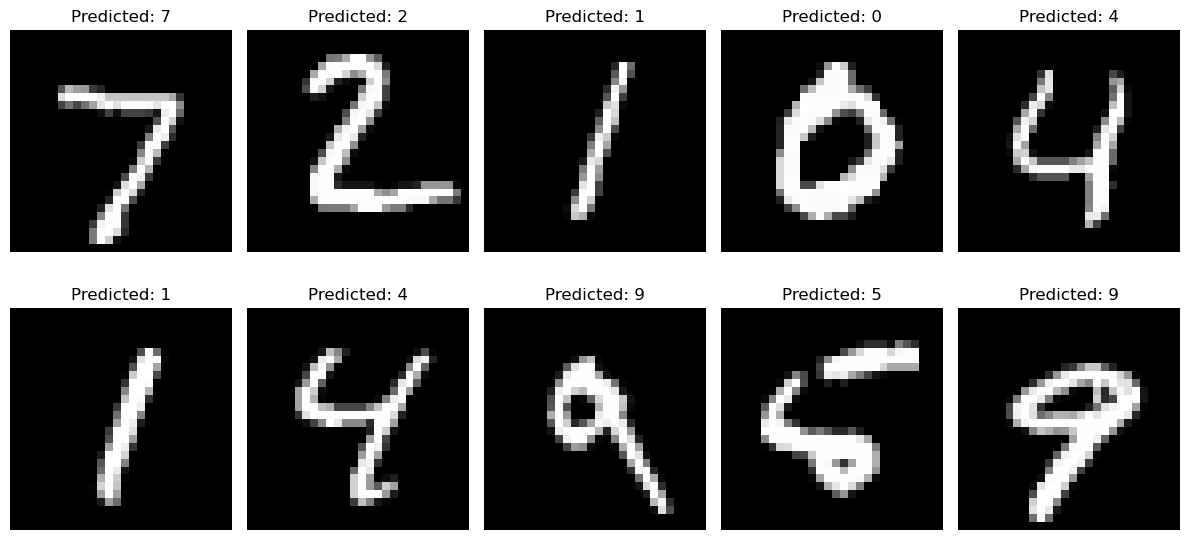

In [17]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    image = X_test.iloc[i].values.reshape(28,28)

    plt.imshow(image, cmap='gray')

    plt.title(f"Predicted: {y_pred[i]}")

    plt.axis('off')

plt.tight_layout()

plt.show()




Explanation

This step visually confirms:


model predictions
digit recognition capability

Final Result

The MLP Neural Network successfully classified handwritten digits with high accuracy using the MNIST dataset.

Advantages of MLP

Learns complex patterns

Good for image classification

High prediction accuracy

Limitations
Training time is high
Requires more computational power
Sensitive to hyperparameters

Viva Questions

Q1. What is MLP?


MLP is a feedforward artificial neural network having input, hidden, and output layers.


Q2. Why normalize data?


Normalization improves training speed and convergence.


Q3. Why use ReLU?


ReLU avoids vanishing gradient problems and trains faster.


Q4. What is backpropagation?


It is the process of updating neural network weights using error gradients.

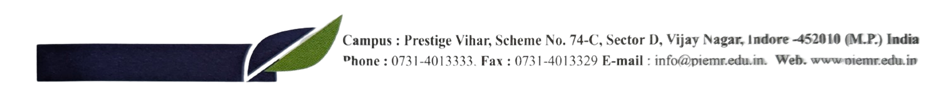